# Question 1 Random Forest: Full Trait Model

This notebook evaluates the custom CSC 466 random forest using `data/processed/breed_forest_full.csv`.

This version keeps each AKC trait rating as its own predictor, while `Coat Type` and `Coat Length` remain categorical.

In [1]:
from pathlib import Path
import sys

from sklearn.metrics import classification_report

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.randomForest.gridSearch import build_rf, run_grid_search
from models.randomForest.rf_analysis_utils import (
    LABEL_ORDER,
    collect_split_counts,
    feature_profiles,
    load_train_test_data,
    make_prediction_results,
    plot_confusion,
)

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_forest_full.csv"
GRID_PATH = PROJECT_ROOT / "models" / "randomForest" / "rf_grid_search_params.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question1" / "rf_test_predictions.csv"

best_params = run_grid_search(DATA_PATH, GRID_PATH)

In [3]:
X, y, attributes, X_train, X_test, y_train, y_test = load_train_test_data(DATA_PATH)

## Final Test Results

The model is trained on the training split using the best cross-validation parameters, then evaluated on the held-out test split. Macro F1 is useful here because the three popularity tiers are not perfectly balanced.

In [4]:
best_rf = build_rf(best_params, seed=42)
best_rf.fit(X_train, y_train, attributes)
test_predictions = best_rf.predict(X_test)

## Model Interpretation

These tables show which features the forest split on most often and how average feature values differ across the actual popularity tiers.

In [5]:
split_importance = collect_split_counts(best_rf.forest)
split_importance

,Feature,Split Count
0,Barking Level,45
1,Watchdog/Protective Nature,39
2,Good With Other Dogs,32
3,Coat Grooming Frequency,28
4,Openness To Strangers,27
5,Shedding Level,26
6,Trainability Level,22
7,Energy Level,20
8,Affectionate With Family,17
9,Mental Stimulation Needs,16


In [6]:
trait_profile, category_profile = feature_profiles(X, y, LABEL_ORDER)
trait_profile

Popularity_Tier,High Popularity,Medium Popularity,Low Popularity
Affectionate With Family,4.65,4.46,4.47
Good With Young Children,4.37,3.70,3.73
Good With Other Dogs,3.82,3.29,3.62
Shedding Level,2.78,2.62,2.44
Coat Grooming Frequency,2.49,2.30,2.09
Drooling Level,1.90,1.88,1.58
Openness To Strangers,3.76,3.55,3.25
Playfulness Level,4.00,3.64,3.44
Watchdog/Protective Nature,3.76,3.92,3.49
Adaptability Level,4.08,3.71,3.66


In [7]:
category_profile

,Coat Type,Coat Length
Popularity_Tier,,
High Popularity,Smooth,Short
Medium Popularity,Smooth,Medium
Low Popularity,Smooth,Short


In [8]:
print(classification_report(y_test, test_predictions, labels=LABEL_ORDER, zero_division=0))

                   precision    recall  f1-score   support

  High Popularity       0.75      0.30      0.43        10
Medium Popularity       0.57      0.53      0.55        15
   Low Popularity       0.52      0.75      0.62        16

         accuracy                           0.56        41
        macro avg       0.61      0.53      0.53        41
     weighted avg       0.60      0.56      0.55        41



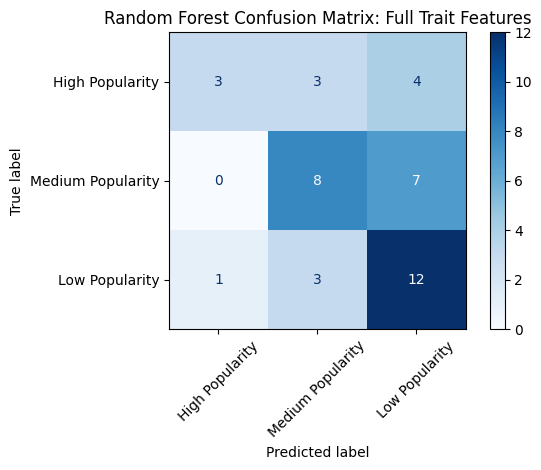

In [9]:
plot_confusion(y_test, test_predictions, "Random Forest Confusion Matrix: Full Trait Features")

## Prediction CSV

This output compares each test-set breed's actual popularity tier to the tier predicted by the full-trait random forest model. `Average Rank` is included for interpretation only; it is not used as a predictor.

In [10]:
PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

prediction_results = make_prediction_results(
    DATA_PATH,
    PROJECT_ROOT / "data" / "interim" / "breed_ranks.csv",
    X_test,
    y_test,
    test_predictions,
)

prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Average Rank,Actual Popularity Tier,Predicted Popularity Tier,Correct
0,Doberman Pinscher,15.5,High Popularity,Medium Popularity,False
1,Dogue de Bordeaux,73.2,Medium Popularity,Medium Popularity,True
2,Sussex Spaniel,174.3,Low Popularity,Low Popularity,True
3,Australian Cattle Dog,53.1,Medium Popularity,Low Popularity,False
4,Maltese,34.8,High Popularity,Low Popularity,False
5,Silky Terrier,108.5,Medium Popularity,Low Popularity,False
6,Yorkshire Terrier,10.4,High Popularity,High Popularity,True
7,Chinese Shar-Pei,65.5,Medium Popularity,Medium Popularity,True
8,Lakeland Terrier,145.5,Low Popularity,Low Popularity,True
9,Akita,50.6,Medium Popularity,Medium Popularity,True
